# TP3 — Clasificando informales en la EPH (Grupo 7)

**Integrantes:**

1.   Antony Araujo Guevara
2.   Erick Huamanchumo Luis


Este notebook comienza **después de haber creado la base final**. Solo requiere subir el archivo:

`EPH_base_final_2024T4_2025T4.xlsx`

La hoja utilizada es `base_final_ocupados`. La variable objetivo del grupo 7 es `lower_tier_informal`:

- `1`: asalariado informal *lower-tier*.
- `0`: otro asalariado clasificable.

El notebook resuelve, en orden, los incisos del TP3.



## Configuración inicial y carga de la base

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from google.colab import files

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

archivos = files.upload()
nombre_archivo = "EPH_base_final_2024T4_2025T4.xlsx"
if nombre_archivo not in archivos:
    raise FileNotFoundError(f"Debe subir {nombre_archivo}")

ocupados = pd.read_excel(
    nombre_archivo,
    sheet_name="base_final_ocupados",
    engine="openpyxl"
)
print("Dimensión de la hoja:", ocupados.shape)
print(ocupados["ANO4"].value_counts().sort_index())


Saving EPH_base_final_2024T4_2025T4.xlsx to EPH_base_final_2024T4_2025T4.xlsx
Dimensión de la hoja: (40830, 57)
ANO4
2024    21132
2025    19698
Name: count, dtype: int64


# A.1 — Separación temporal y muestra longitudinal

- Entrenamiento: 2024.
- Testeo: 2025.
- Unión longitudinal: `CODUSU`, `NRO_HOGAR` y `COMPONENTE`.
- Se excluyen predictores que forman directamente la variable objetivo para evitar fuga de información.


In [3]:
variables_identificacion = ["CODUSU", "NRO_HOGAR", "COMPONENTE"]

variables_X = [
    "es_mujer",
    "vive_en_pareja",
    "tiene_cobertura_medica",
    "asiste_actualmente",
    "es_subocupado",
    "CH06",
    "edad2",
    "educ",
    "horas_totales_ocupado",
    "nhogar",
    "P21",
    "P47T"
]

variable_y = "lower_tier_informal"

variables_fuga = [
    "PP07H", "PP04C", "sin_descuento_jubilatorio",
    "establecimiento_hasta_5", "condicion_asalariada",
    "EMPLEO", "empleo_informal_indec"
]

variables_necesarias = variables_identificacion + ["ANO4", "PONDERA", variable_y] + variables_X
faltantes = [v for v in variables_necesarias if v not in ocupados.columns]
if faltantes:
    raise KeyError(f"Faltan variables: {faltantes}")

base_modelo = ocupados.loc[ocupados[variable_y].notna()].copy().reset_index(drop=True)
base_modelo[variable_y] = pd.to_numeric(base_modelo[variable_y], errors="raise").astype(int)
assert set(base_modelo[variable_y].unique()).issubset({0, 1})

clave_persona = ["CODUSU", "NRO_HOGAR", "COMPONENTE"]
duplicados = base_modelo.duplicated(["ANO4"] + clave_persona, keep=False).sum()
if duplicados > 0:
    raise ValueError(f"Hay {duplicados} filas en claves duplicadas dentro de un año")

base_2024 = base_modelo.loc[base_modelo["ANO4"].eq(2024)].copy().reset_index(drop=True)
base_2025 = base_modelo.loc[base_modelo["ANO4"].eq(2025)].copy().reset_index(drop=True)

ocupados_X_2024_con_id = base_2024[variables_identificacion + variables_X].copy()
ocupados_X_2025_con_id = base_2025[variables_identificacion + variables_X].copy()
ocupados_X_2024 = ocupados_X_2024_con_id[variables_X].copy()
ocupados_X_2025 = ocupados_X_2025_con_id[variables_X].copy()
y_2024 = base_2024[variable_y].copy().rename("y_2024")
y_2025 = base_2025[variable_y].copy().rename("y_2025")

print("X 2024:", ocupados_X_2024.shape, "| y 2024:", y_2024.shape)
print("X 2025:", ocupados_X_2025.shape, "| y 2025:", y_2025.shape)


X 2024: (11233, 12) | y 2024: (11233,)
X 2025: (9957, 12) | y 2025: (9957,)


In [4]:
informalidad_2024 = (
    base_2024[clave_persona + [variable_y]]
    .copy()
    .rename(columns={variable_y: "informal_2024"})
)

base_MM_2025 = (
    base_2025[clave_persona + variables_X + ["PONDERA", variable_y]]
    .copy()
    .rename(columns={variable_y: "y_2025"})
)

ocupados_2025_MM_con_id = base_MM_2025.merge(
    informalidad_2024,
    on=clave_persona,
    how="inner",
    validate="one_to_one"
)

variables_X_MM = variables_X + ["informal_2024"]
ocupados_X_2025_MM = ocupados_2025_MM_con_id[variables_X_MM].copy().reset_index(drop=True)
y_2025_MM = ocupados_2025_MM_con_id["y_2025"].astype(int).reset_index(drop=True).rename("y_2025_MM")

assert len(ocupados_X_2025_MM) == len(y_2025_MM)
print("Muestra longitudinal:", ocupados_X_2025_MM.shape)
print("Retención sobre test:", f"{100*len(ocupados_X_2025_MM)/len(base_2025):.2f}%")

resumen_bases = pd.DataFrame({
    "Objeto": ["ocupados_X_2024", "y_2024", "ocupados_X_2025", "y_2025", "ocupados_X_2025_MM", "y_2025_MM"],
    "Filas": [len(ocupados_X_2024), len(y_2024), len(ocupados_X_2025), len(y_2025), len(ocupados_X_2025_MM), len(y_2025_MM)],
    "Columnas": [ocupados_X_2024.shape[1], 1, ocupados_X_2025.shape[1], 1, ocupados_X_2025_MM.shape[1], 1]
})
resumen_bases


Muestra longitudinal: (3013, 13)
Retención sobre test: 30.26%


,Objeto,Filas,Columnas
0,ocupados_X_2024,11233,12
1,y_2024,11233,1
2,ocupados_X_2025,9957,12
3,y_2025,9957,1
4,ocupados_X_2025_MM,3013,13
5,y_2025_MM,3013,1


In [5]:
tabla_transicion = pd.crosstab(
    ocupados_2025_MM_con_id["informal_2024"],
    ocupados_2025_MM_con_id["y_2025"],
    rownames=["Condición en 2024"],
    colnames=["Condición en 2025"],
    margins=True
).rename(index={0: "No lower-tier", 1: "Lower-tier"}, columns={0: "No lower-tier", 1: "Lower-tier"})
tabla_transicion


Condición en 2025,No lower-tier,Lower-tier,All
Condición en 2024,,,
No lower-tier,2472,113,2585
Lower-tier,128,300,428
All,2600,413,3013


# A.2 — Balance Table: Train vs. Test Sample

In [6]:
etiquetas_variables = {
    "es_mujer": "Mujer",
    "vive_en_pareja": "Vive en pareja",
    "tiene_cobertura_medica": "Tiene cobertura médica",
    "asiste_actualmente": "Asiste actualmente",
    "es_subocupado": "Subocupado",
    "CH06": "Edad",
    "edad2": "Edad al cuadrado",
    "educ": "Años de educación",
    "horas_totales_ocupado": "Horas totales trabajadas",
    "nhogar": "Miembros del hogar",
    "P21": "Ingreso ocupación principal",
    "P47T": "Ingreso total individual"
}

def crear_tabla_balance(X_2024, X_2025, variables, etiquetas):
    resultados = []
    for variable in variables:
        x = pd.to_numeric(X_2024[variable], errors="coerce").dropna().astype(float)
        z = pd.to_numeric(X_2025[variable], errors="coerce").dropna().astype(float)
        t, p = stats.ttest_ind(x, z, equal_var=False, nan_policy="omit")
        diferencia = z.mean() - x.mean()
        sd_combinado = np.sqrt((x.var(ddof=1) + z.var(ddof=1)) / 2)
        smd = diferencia / sd_combinado if sd_combinado > 0 else np.nan
        resultados.append({
            "Variable": etiquetas.get(variable, variable),
            "Nombre_original": variable,
            "N_2024": len(x), "Media_2024": x.mean(), "DE_2024": x.std(ddof=1),
            "N_2025": len(z), "Media_2025": z.mean(), "DE_2025": z.std(ddof=1),
            "Diferencia_2025_2024": diferencia,
            "Estadistico_t": t, "Valor_p": p, "SMD": smd
        })
    return pd.DataFrame(resultados)

def estrellas(p):
    if pd.isna(p): return ""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

tabla_balance = crear_tabla_balance(ocupados_X_2024, ocupados_X_2025, variables_X, etiquetas_variables)
tabla_balance["Significancia"] = tabla_balance["Valor_p"].apply(estrellas)
tabla_balance_formateada = tabla_balance[[
    "Variable", "N_2024", "Media_2024", "DE_2024",
    "N_2025", "Media_2025", "DE_2025",
    "Diferencia_2025_2024", "Valor_p", "Significancia", "SMD"
]].copy()
tabla_balance_formateada.round(4)


,Variable,N_2024,Media_2024,DE_2024,N_2025,Media_2025,DE_2025,Diferencia_2025_2024,Valor_p,Significancia,SMD
0,Mujer,11233,0.4232,0.4941,9957,0.4332,0.4955,0.0099,0.1443,,0.0201
1,Vive en pareja,11233,0.5213,0.4996,9957,0.5220,0.4995,0.0007,0.9162,,0.0014
2,Tiene cobertura médica,11226,0.7967,0.4025,9954,0.7962,0.4029,-0.0006,0.9196,,-0.0014
3,Asiste actualmente,11233,0.0828,0.2756,9957,0.0785,0.2690,-0.0043,0.2561,,-0.0156
4,Subocupado,11233,0.0749,0.2632,9957,0.0691,0.2536,-0.0058,0.1043,,-0.0223
5,Edad,11233,39.7871,12.3442,9957,40.2241,12.4637,0.4370,0.0105,**,0.0352
6,Edad al cuadrado,11233,"1,735.3745","1,040.5968",9957,"1,773.3047","1,064.7967",37.9302,0.0089,***,0.0360
7,Años de educación,11149,12.6797,3.1783,9877,12.7256,3.1590,0.0459,0.2942,,0.0145
8,Horas totales trabajadas,11233,39.4884,31.4549,9957,39.9908,38.4879,0.5024,0.3020,,0.0143
9,Miembros del hogar,11233,3.4825,1.7805,9957,3.4470,1.7590,-0.0355,0.1451,,-0.0201


In [7]:
tabla_ausentes = pd.DataFrame({
    "Variable": [etiquetas_variables.get(v, v) for v in variables_X],
    "Ausentes_2024": [ocupados_X_2024[v].isna().sum() for v in variables_X],
    "Porcentaje_ausentes_2024": [100*ocupados_X_2024[v].isna().mean() for v in variables_X],
    "Ausentes_2025": [ocupados_X_2025[v].isna().sum() for v in variables_X],
    "Porcentaje_ausentes_2025": [100*ocupados_X_2025[v].isna().mean() for v in variables_X]
})
tabla_ausentes.round(2)


,Variable,Ausentes_2024,Porcentaje_ausentes_2024,Ausentes_2025,Porcentaje_ausentes_2025
0,Mujer,0,0.0000,0,0.0000
1,Vive en pareja,0,0.0000,0,0.0000
2,Tiene cobertura médica,7,0.0600,3,0.0300
3,Asiste actualmente,0,0.0000,0,0.0000
4,Subocupado,0,0.0000,0,0.0000
5,Edad,0,0.0000,0,0.0000
6,Edad al cuadrado,0,0.0000,0,0.0000
7,Años de educación,84,0.7500,80,0.8000
8,Horas totales trabajadas,0,0.0000,0,0.0000
9,Miembros del hogar,0,0.0000,0,0.0000


# B.1 — Regresiones logísticas

- Modelo 1: `y_2024 ~ X_2024`.
- Modelo 2 MM: `y_2025 ~ X_2025 + informal_2024` sobre la muestra longitudinal.
- Las imputaciones se realizan con medianas de la muestra usada para cada estimación.


In [8]:
variables_modelo = variables_X.copy()

def preparar_caracteristicas(base, variables, agregar_informalidad_previa=False, medianas=None):
    columnas = variables + (["informal_2024"] if agregar_informalidad_previa else [])
    X = base[columnas].copy()
    X["edad2"] = X["edad2"] / 100
    X["horas_totales_ocupado"] = X["horas_totales_ocupado"] / 10
    X["P21"] = X["P21"] / 1_000_000
    X["P47T"] = X["P47T"] / 1_000_000
    if medianas is None:
        medianas = X.median(numeric_only=True)
    X = X.fillna(medianas).astype(float)
    X = sm.add_constant(X, has_constant="add")
    return X, medianas

X_modelo_1, medianas_modelo_1 = preparar_caracteristicas(base_2024, variables_modelo)
y_modelo_1 = base_2024[variable_y].astype(int).reset_index(drop=True)
X_modelo_1 = X_modelo_1.reset_index(drop=True)
modelo_1 = sm.Logit(y_modelo_1, X_modelo_1).fit(maxiter=200, disp=False)

X_modelo_2, medianas_modelo_2 = preparar_caracteristicas(
    ocupados_2025_MM_con_id, variables_modelo, agregar_informalidad_previa=True
)
y_modelo_2 = ocupados_2025_MM_con_id["y_2025"].astype(int).reset_index(drop=True)
X_modelo_2 = X_modelo_2.reset_index(drop=True)
modelo_2 = sm.Logit(y_modelo_2, X_modelo_2).fit(maxiter=200, disp=False)

assert modelo_1.mle_retvals["converged"] and modelo_2.mle_retvals["converged"]
print("Modelo 1:", int(modelo_1.nobs), "observaciones | Pseudo R²:", round(modelo_1.prsquared, 4))
print("Modelo 2:", int(modelo_2.nobs), "observaciones | Pseudo R²:", round(modelo_2.prsquared, 4))


Modelo 1: 11233 observaciones | Pseudo R²: 0.3597
Modelo 2: 3013 observaciones | Pseudo R²: 0.529


In [13]:
def extraer_resultados(modelo, nombre):
    return pd.DataFrame({
        "Variable": modelo.params.index,
        f"Coeficiente_{nombre}": modelo.params.values,
        f"Std_Error_{nombre}": modelo.bse.values,
        f"Odds_Ratio_{nombre}": np.exp(modelo.params.values),
        f"p_valor_{nombre}": modelo.pvalues.values
    })


resultados_modelo_1 = extraer_resultados(
    modelo_1,
    "M1"
)

resultados_modelo_2 = extraer_resultados(
    modelo_2,
    "M2"
)

tabla_resultados_logit = resultados_modelo_1.merge(
    resultados_modelo_2,
    on="Variable",
    how="outer"
)

In [14]:
etiquetas_modelo = {
    "const": "Constante",
    "es_mujer": "Mujer",
    "vive_en_pareja": "Vive en pareja",
    "tiene_cobertura_medica": "Tiene cobertura médica",
    "asiste_actualmente": "Asiste actualmente",
    "es_subocupado": "Subocupado",
    "CH06": "Edad",
    "edad2": "Edad² / 100",
    "educ": "Años de educación",
    "horas_totales_ocupado": "Horas trabajadas / 10",
    "nhogar": "Miembros del hogar",
    "P21": "P21, millones de pesos",
    "P47T": "P47T, millones de pesos",
    "informal_2024": "Informal lower-tier en 2024"
}

tabla_resultados_logit["Característica"] = (
    tabla_resultados_logit["Variable"]
    .map(etiquetas_modelo)
    .fillna(tabla_resultados_logit["Variable"])
)

In [15]:
orden_variables = [
    "const",
    "es_mujer",
    "vive_en_pareja",
    "tiene_cobertura_medica",
    "asiste_actualmente",
    "es_subocupado",
    "CH06",
    "edad2",
    "educ",
    "horas_totales_ocupado",
    "nhogar",
    "P21",
    "P47T",
    "informal_2024"
]

tabla_resultados_logit["Orden"] = (
    tabla_resultados_logit["Variable"]
    .map({
        variable: posicion
        for posicion, variable in enumerate(orden_variables)
    })
)

tabla_resultados_logit = (
    tabla_resultados_logit
    .sort_values("Orden")
    .reset_index(drop=True)
)

In [17]:
tabla_visual_logit = tabla_resultados_logit[
    [
        "Característica",
        "Coeficiente_M1",
        "Std_Error_M1",
        "Odds_Ratio_M1",
        "Coeficiente_M2",
        "Std_Error_M2",
        "Odds_Ratio_M2"
    ]
].copy()

tabla_visual_logit.columns = pd.MultiIndex.from_tuples([
    ("", "Característica"),
    ("Modelo 1 — Train 2024", "Coeficiente"),
    ("Modelo 1 — Train 2024", "Std. Error"),
    ("Modelo 1 — Train 2024", "Odds Ratio"),
    ("Modelo 2 MM — 2025", "Coeficiente"),
    ("Modelo 2 MM — 2025", "Std. Error"),
    ("Modelo 2 MM — 2025", "Odds Ratio")
])

tabla_visual_logit.style.format(
    {
        ("Modelo 1 — Train 2024", "Coeficiente"): "{:.3f}",
        ("Modelo 1 — Train 2024", "Std. Error"): "{:.3f}",
        ("Modelo 1 — Train 2024", "Odds Ratio"): "{:.3f}",
        ("Modelo 2 MM — 2025", "Coeficiente"): "{:.3f}",
        ("Modelo 2 MM — 2025", "Std. Error"): "{:.3f}",
        ("Modelo 2 MM — 2025", "Odds Ratio"): "{:.3f}"
    },
    na_rep=""
).set_properties(
    **{
        "text-align": "center",
        "font-size": "10pt"
    }
).set_properties(
    subset=[("", "Característica")],
    **{
        "text-align": "left",
        "font-weight": "bold"
    }
).set_table_styles([
    {
        "selector": "th",
        "props": [
            ("background-color", "#17365D"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("border", "1px solid white")
        ]
    },
    {
        "selector": "tbody tr:nth-child(odd)",
        "props": [
            ("background-color", "#DDEBF7")
        ]
    },
    {
        "selector": "tbody tr:nth-child(even)",
        "props": [
            ("background-color", "#F2F2F2")
        ]
    }
])

In [31]:
# Instalar python-docx si no está instalado
!pip install python-docx

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

def crear_word_tabla_logit(tabla_resultados, nombre_archivo):
    document = Document()
    document.add_heading('Resultados de Regresión Logística', level=1)
    document.add_paragraph('La siguiente tabla presenta los coeficientes, errores estándar y Odds Ratios para los Modelos 1 y 2.')

    num_data_rows = tabla_resultados.shape[0]
    num_cols = tabla_resultados.shape[1]

    # Crear la tabla con 2 filas de encabezado + filas de datos
    table = document.add_table(rows=num_data_rows + 2, cols=num_cols)
    table.style = 'Table Grid'

    # Establecer anchos de columna (ejemplo, ajustar según el contenido)
    # Esto es un enfoque general; podría ser necesario un ajuste fino
    col_widths = [Inches(1.5)] + [Inches(0.9)] * (num_cols - 1)
    for i, width in enumerate(col_widths):
        table.columns[i].width = width

    # --- Rellenar la fila de encabezado superior (Nivel 0 del MultiIndex) ---
    hdr_cells_0 = table.rows[0].cells

    level0_headers = [col[0] for col in tabla_resultados.columns]

    unique_level0_headers = []
    level0_spans = [] # Cuántas subcolumnas abarca cada encabezado de nivel 0

    if level0_headers: # Asegurarse de que haya al menos un encabezado
        current_header = level0_headers[0]
        current_span = 1
        for i in range(1, len(level0_headers)):
            if level0_headers[i] == current_header:
                current_span += 1
            else:
                unique_level0_headers.append(current_header)
                level0_spans.append(current_span)
                current_header = level0_headers[i]
                current_span = 1
        unique_level0_headers.append(current_header)
        level0_spans.append(current_span)

    # Ahora rellenar la primera fila de encabezado con celdas fusionadas
    current_col = 0
    for i, header_text in enumerate(unique_level0_headers):
        span = level0_spans[i]

        # Fusionar celdas si span > 1
        if span > 1:
            merged_cell = hdr_cells_0[current_col].merge(hdr_cells_0[current_col + span - 1])
            cell = merged_cell
        else:
            cell = hdr_cells_0[current_col]

        cell.text = header_text
        paragraph = cell.paragraphs[0]
        paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
        run = paragraph.runs[0]
        run.bold = True
        run.font.size = Pt(10) # Establecer tamaño de fuente para el encabezado
        run.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF) # Color blanco para el texto del encabezado

        # Establecer color de fondo para las celdas del encabezado
        tcPr = cell._element.get_or_add_tcPr()
        tcBg = OxmlElement("w:shd")
        tcBg.set(qn("w:val"), "clear")
        tcBg.set(qn("w:color"), "auto")
        tcBg.set(qn("w:fill"), "17365D") # Azul oscuro
        tcPr.append(tcBg)

        current_col += span

    # --- Rellenar la fila de encabezado inferior (Nivel 1 del MultiIndex) ---
    hdr_cells_1 = table.rows[1].cells
    for i, (level0, level1) in enumerate(tabla_resultados.columns):
        cell = hdr_cells_1[i]
        cell.text = level1
        paragraph = cell.paragraphs[0]
        paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
        run = paragraph.runs[0]
        run.bold = True
        run.font.size = Pt(10) # Establecer tamaño de fuente para el encabezado
        run.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF) # Color blanco para el texto del encabezado

        # Establecer color de fondo para las celdas del encabezado
        tcPr = cell._element.get_or_add_tcPr()
        tcBg = OxmlElement("w:shd")
        tcBg.set(qn("w:val"), "clear")
        tcBg.set(qn("w:color"), "auto")
        tcBg.set(qn("w:fill"), "17365D") # Azul oscuro
        tcPr.append(tcBg)

    # --- Rellenar las filas de datos ---
    for i, row_data in enumerate(tabla_resultados.itertuples(index=False)):
        row_cells = table.rows[i + 2].cells # +2 debido a las dos filas de encabezado
        for j, cell_value in enumerate(row_data):
            cell = row_cells[j]
            cell.text = str(cell_value)
            paragraph = cell.paragraphs[0]
            run = paragraph.runs[0]
            run.font.size = Pt(10) # Establecer tamaño de fuente para las celdas de datos

            if j == 0:  # Primera columna ('Característica')
                paragraph.alignment = WD_ALIGN_PARAGRAPH.LEFT
                run.bold = True
            else:  # Columnas numéricas
                paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER # Alinear números al centro

            # Aplicar colores de banda de fila similares a la salida del Styler
            if (i % 2) == 0: # Fila par
                tcPr = cell._element.get_or_add_tcPr()
                tcBg = OxmlElement("w:shd")
                tcBg.set(qn("w:val"), "clear")
                tcBg.set(qn("w:color"), "auto")
                tcBg.set(qn("w:fill"), "DDEBF7") # Azul claro
                tcPr.append(tcBg)
            else: # Fila impar
                tcPr = cell._element.get_or_add_tcPr()
                tcBg = OxmlElement("w:shd")
                tcBg.set(qn("w:val"), "clear")
                tcBg.set(qn("w:color"), "auto")
                tcBg.set(qn("w:fill"), "F2F2F2") # Gris claro
                tcPr.append(tcBg)

    document.save(nombre_archivo)
    print(f"Tabla guardada en {nombre_archivo}")

nombre_word = (
    "Resultaos_logit.docx"
)

# Asumiendo que 'tabla_visual_logit' es la tabla formateada que se quiere exportar
# Si se desea exportar 'tabla_resultados_logit' sin el formato especial, se puede cambiar aquí
crear_word_tabla_logit(
    tabla_resultados=tabla_visual_logit,
    nombre_archivo=nombre_word
)

Tabla guardada en Resultaos_logit.docx


In [9]:
def extraer_resultados(modelo, nombre):
    return pd.DataFrame({
        "Variable": modelo.params.index,
        f"Coef_{nombre}": modelo.params.values,
        f"EE_{nombre}": modelo.bse.values,
        f"OR_{nombre}": np.exp(modelo.params.values),
        f"p_{nombre}": modelo.pvalues.values
    })

r1 = extraer_resultados(modelo_1, "Modelo_1")
r2 = extraer_resultados(modelo_2, "Modelo_2_MM")
tabla_modelos = r1.merge(r2, on="Variable", how="outer")
tabla_modelos["Sig_Modelo_1"] = tabla_modelos["p_Modelo_1"].apply(estrellas)
tabla_modelos["Sig_Modelo_2_MM"] = tabla_modelos["p_Modelo_2_MM"].apply(estrellas)

etiquetas_modelo = {
    "const":"Constante", "es_mujer":"Mujer", "vive_en_pareja":"Vive en pareja",
    "tiene_cobertura_medica":"Tiene cobertura médica", "asiste_actualmente":"Asiste actualmente",
    "es_subocupado":"Subocupado", "CH06":"Edad", "edad2":"Edad² / 100",
    "educ":"Años de educación", "horas_totales_ocupado":"Horas / 10",
    "nhogar":"Miembros del hogar", "P21":"P21, millones", "P47T":"P47T, millones",
    "informal_2024":"Informal lower-tier en 2024"
}
tabla_modelos["Característica"] = tabla_modelos["Variable"].map(etiquetas_modelo).fillna(tabla_modelos["Variable"])
tabla_modelos_final = tabla_modelos[[
    "Característica", "Coef_Modelo_1", "EE_Modelo_1", "OR_Modelo_1", "p_Modelo_1", "Sig_Modelo_1",
    "Coef_Modelo_2_MM", "EE_Modelo_2_MM", "OR_Modelo_2_MM", "p_Modelo_2_MM", "Sig_Modelo_2_MM"
]].copy()
tabla_modelos_final.round(4)


,Característica,Coef_Modelo_1,EE_Modelo_1,OR_Modelo_1,p_Modelo_1,Sig_Modelo_1,Coef_Modelo_2_MM,EE_Modelo_2_MM,OR_Modelo_2_MM,p_Modelo_2_MM,Sig_Modelo_2_MM
0,Edad,-0.1464,0.0146,0.8638,0.0000,***,-0.1830,0.0398,0.8328,0.0000,***
1,"P21, millones",-1.7405,0.1451,0.1754,0.0000,***,-1.1708,0.4602,0.3101,0.0109,**
2,"P47T, millones",0.2470,0.1070,1.2802,0.0210,**,0.1289,0.3987,1.1376,0.7464,
3,Asiste actualmente,0.2572,0.1095,1.2934,0.0188,**,-0.0213,0.3213,0.9790,0.9472,
4,Constante,4.7769,0.3169,118.7336,0.0000,***,4.1489,0.9065,63.3657,0.0000,***
5,Edad² / 100,0.1656,0.0172,1.1801,0.0000,***,0.2003,0.0463,1.2217,0.0000,***
6,Años de educación,-0.0631,0.0115,0.9389,0.0000,***,-0.0458,0.0299,0.9552,0.1255,
7,Mujer,-0.3497,0.0693,0.7049,0.0000,***,0.0993,0.1822,1.1044,0.5857,
8,Subocupado,0.3678,0.0998,1.4445,0.0002,***,0.2276,0.2819,1.2555,0.4195,
9,Horas / 10,0.0110,0.0071,1.0111,0.1195,,-0.0403,0.0582,0.9605,0.4888,


In [10]:
efectos_marginales_1 = modelo_1.get_margeff(at="overall", method="dydx")
efectos_marginales_2 = None


In [11]:
efectos_marginales_2 = modelo_2.get_margeff(at="overall", method="dydx")
tabla_ame_1 = efectos_marginales_1.summary_frame().reset_index().rename(columns={
    "index":"Variable", "dy/dx":"AME_Modelo_1", "Std. Err.":"EE_AME_Modelo_1", "Pr(>|z|)":"p_AME_Modelo_1"
})
tabla_ame_2 = efectos_marginales_2.summary_frame().reset_index().rename(columns={
    "index":"Variable", "dy/dx":"AME_Modelo_2_MM", "Std. Err.":"EE_AME_Modelo_2_MM", "Pr(>|z|)":"p_AME_Modelo_2_MM"
})
tabla_efectos_marginales = tabla_ame_1.merge(tabla_ame_2, on="Variable", how="outer")
tabla_efectos_marginales["AME_Modelo_1_pp"] = 100*tabla_efectos_marginales["AME_Modelo_1"]
tabla_efectos_marginales["AME_Modelo_2_MM_pp"] = 100*tabla_efectos_marginales["AME_Modelo_2_MM"]
tabla_efectos_marginales.round(4)


,Variable,AME_Modelo_1,EE_AME_Modelo_1,z_x,p_AME_Modelo_1,Conf. Int. Low_x,Cont. Int. Hi._x,AME_Modelo_2_MM,EE_AME_Modelo_2_MM,z_y,p_AME_Modelo_2_MM,Conf. Int. Low_y,Cont. Int. Hi._y,AME_Modelo_1_pp,AME_Modelo_2_MM_pp
0,CH06,-0.0132,0.0013,-10.1865,0.0000,-0.0157,-0.0106,-0.0096,0.0021,-4.6042,0.0000,-0.0136,-0.0055,-1.3176,-0.9570
1,P21,-0.1566,0.0130,-12.0885,0.0000,-0.1820,-0.1312,-0.0612,0.0241,-2.5413,0.0110,-0.1085,-0.0140,-15.6633,-6.1233
2,P47T,0.0222,0.0096,2.3090,0.0209,0.0034,0.0411,0.0067,0.0209,0.3233,0.7464,-0.0341,0.0476,2.2231,0.6742
3,asiste_actualmente,0.0231,0.0099,2.3498,0.0188,0.0038,0.0425,-0.0011,0.0168,-0.0662,0.9472,-0.0340,0.0318,2.3150,-0.1112
4,edad2,0.0149,0.0015,9.7277,0.0000,0.0119,0.0179,0.0105,0.0024,4.3384,0.0000,0.0057,0.0152,1.4907,1.0474
5,educ,-0.0057,0.0010,-5.4746,0.0000,-0.0077,-0.0036,-0.0024,0.0016,-1.5316,0.1256,-0.0055,0.0007,-0.5677,-0.2397
6,es_mujer,-0.0315,0.0062,-5.0602,0.0000,-0.0437,-0.0193,0.0052,0.0095,0.5452,0.5856,-0.0135,0.0239,-3.1474,0.5194
7,es_subocupado,0.0331,0.0090,3.6947,0.0002,0.0155,0.0507,0.0119,0.0147,0.8074,0.4195,-0.0170,0.0408,3.3099,1.1901
8,horas_totales_ocupado,0.0010,0.0006,1.5571,0.1194,-0.0003,0.0022,-0.0021,0.0030,-0.6924,0.4887,-0.0081,0.0039,0.0994,-0.2109
9,informal_2024,NaN,NaN,NaN,NaN,NaN,NaN,0.1439,0.0070,20.5346,0.0000,0.1302,0.1576,NaN,14.3900


In [12]:
tabla_ajuste = pd.DataFrame({
    "Indicador": ["Observaciones", "Log-likelihood", "Pseudo R² McFadden", "AIC", "BIC", "Convergió"],
    "Modelo 1": [int(modelo_1.nobs), modelo_1.llf, modelo_1.prsquared, modelo_1.aic, modelo_1.bic, modelo_1.mle_retvals["converged"]],
    "Modelo 2 MM": [int(modelo_2.nobs), modelo_2.llf, modelo_2.prsquared, modelo_2.aic, modelo_2.bic, modelo_2.mle_retvals["converged"]]
})

def punto_giro_edad(modelo):
    return -modelo.params["CH06"]*100/(2*modelo.params["edad2"])

print("Punto de giro M1:", round(punto_giro_edad(modelo_1), 2))
print("Punto de giro M2:", round(punto_giro_edad(modelo_2), 2))
tabla_ajuste


Punto de giro M1: 44.19
Punto de giro M2: 45.68


,Indicador,Modelo 1,Modelo 2 MM
0,Observaciones,11233,3013
1,Log-likelihood,"-3,372.9988",-567.0652
2,Pseudo R² McFadden,0.3597,0.5290
3,AIC,"6,771.9976","1,162.1304"
4,BIC,"6,867.2435","1,246.2801"
5,Convergió,True,True


# B.2 — Probabilidad estimada en 2025 según años de educación

In [18]:
X_2025_para_modelo_1 = ocupados_2025_MM_con_id[variables_modelo].copy()
X_2025_para_modelo_1["edad2"] /= 100
X_2025_para_modelo_1["horas_totales_ocupado"] /= 10
X_2025_para_modelo_1["P21"] /= 1_000_000
X_2025_para_modelo_1["P47T"] /= 1_000_000
X_2025_para_modelo_1 = X_2025_para_modelo_1.fillna(medianas_modelo_1).astype(float)
X_2025_para_modelo_1 = sm.add_constant(X_2025_para_modelo_1, has_constant="add")
X_2025_para_modelo_1 = X_2025_para_modelo_1[modelo_1.params.index]

probabilidad_2025_modelo_1 = modelo_1.predict(X_2025_para_modelo_1)
assert probabilidad_2025_modelo_1.between(0,1).all()

datos_grafico_B2 = pd.DataFrame({
    "educ": X_2025_para_modelo_1["educ"],
    "probabilidad_estimada": probabilidad_2025_modelo_1,
    "informal_observado": ocupados_2025_MM_con_id["y_2025"].astype(int).to_numpy(),
    "PONDERA": ocupados_2025_MM_con_id["PONDERA"].to_numpy()
})

resumen_educacion = datos_grafico_B2.groupby("educ", as_index=False).agg(
    cantidad_observaciones=("probabilidad_estimada", "size"),
    probabilidad_media_estimada=("probabilidad_estimada", "mean"),
    proporcion_observada=("informal_observado", "mean")
)
print("Probabilidad media predicha:", round(datos_grafico_B2["probabilidad_estimada"].mean(),4))
print("Incidencia observada:", round(datos_grafico_B2["informal_observado"].mean(),4))


Probabilidad media predicha: 0.1368
Incidencia observada: 0.1371


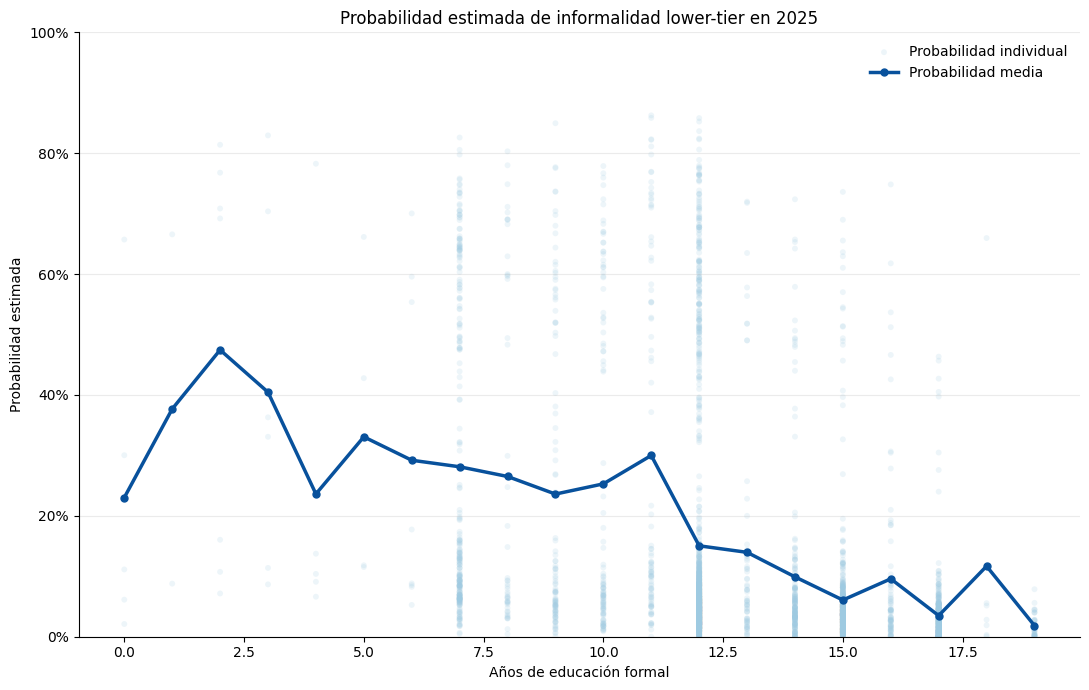

In [19]:
fig, ax = plt.subplots(figsize=(11,7))
ax.scatter(datos_grafico_B2["educ"], datos_grafico_B2["probabilidad_estimada"],
           color="#9ecae1", alpha=0.18, s=18, edgecolors="none", label="Probabilidad individual")
ax.plot(resumen_educacion["educ"], resumen_educacion["probabilidad_media_estimada"],
        color="#08519c", linewidth=2.5, marker="o", markersize=5, label="Probabilidad media")
ax.set_title("Probabilidad estimada de informalidad lower-tier en 2025")
ax.set_xlabel("Años de educación formal")
ax.set_ylabel("Probabilidad estimada")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylim(0,1); ax.grid(axis="y", alpha=.25); ax.legend(frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("TP3_B2_probabilidad_educacion_grupo7.png", dpi=300, bbox_inches="tight")
plt.show()


# C.1 — Matrices de confusión, métricas y curvas ROC

In [20]:
probabilidad_modelo_1 = np.asarray(modelo_1.predict(X_2025_para_modelo_1))
probabilidad_modelo_2 = np.asarray(modelo_2.predict(X_modelo_2))
y_observado_2025 = np.asarray(y_modelo_2, dtype=int)
umbral = 0.5
prediccion_modelo_1 = (probabilidad_modelo_1 > umbral).astype(int)
prediccion_modelo_2 = (probabilidad_modelo_2 > umbral).astype(int)
matriz_modelo_1 = confusion_matrix(y_observado_2025, prediccion_modelo_1, labels=[0,1])
matriz_modelo_2 = confusion_matrix(y_observado_2025, prediccion_modelo_2, labels=[0,1])
print("M1", matriz_modelo_1, sep="\n")
print("M2", matriz_modelo_2, sep="\n")


M1
[[2477  123]
 [ 191  222]]
M2
[[2528   72]
 [ 153  260]]


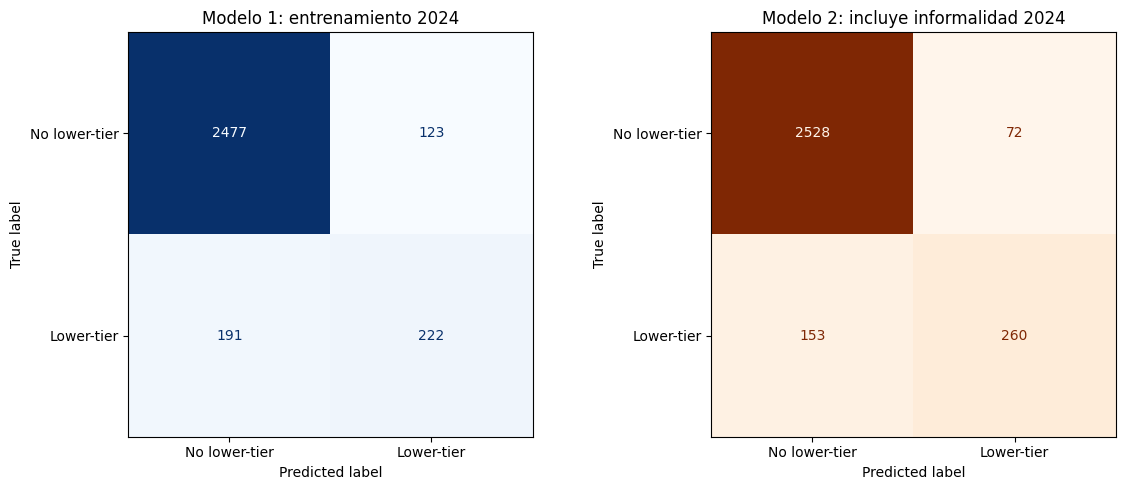

In [21]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
ConfusionMatrixDisplay(matriz_modelo_1, display_labels=["No lower-tier","Lower-tier"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Modelo 1: entrenamiento 2024")
ConfusionMatrixDisplay(matriz_modelo_2, display_labels=["No lower-tier","Lower-tier"]).plot(
    ax=axes[1], cmap="Oranges", colorbar=False, values_format="d")
axes[1].set_title("Modelo 2: incluye informalidad 2024")
plt.tight_layout()
plt.savefig("TP3_C1_matrices_confusion_grupo7.png", dpi=300, bbox_inches="tight")
plt.show()


In [22]:
def evaluar_modelo(y, p, nombre, umbral=.5):
    yh = (p > umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yh, labels=[0,1]).ravel()
    return {
        "Modelo":nombre, "Umbral":umbral,
        "Verdaderos negativos":tn, "Falsos positivos":fp,
        "Falsos negativos":fn, "Verdaderos positivos":tp,
        "Accuracy":accuracy_score(y,yh),
        "Precision":precision_score(y,yh,zero_division=0),
        "Sensibilidad_Recall":recall_score(y,yh,zero_division=0),
        "Especificidad":tn/(tn+fp),
        "F1_score":f1_score(y,yh,zero_division=0),
        "ROC_AUC":roc_auc_score(y,p)
    }

tabla_metricas = pd.DataFrame([
    evaluar_modelo(y_observado_2025, probabilidad_modelo_1, "Modelo 1: entrenamiento 2024"),
    evaluar_modelo(y_observado_2025, probabilidad_modelo_2, "Modelo 2 MM")
])
tabla_metricas_formateada = tabla_metricas.copy()
cols_pct = ["Accuracy","Precision","Sensibilidad_Recall","Especificidad","F1_score","ROC_AUC"]
tabla_metricas_formateada[cols_pct] = 100*tabla_metricas_formateada[cols_pct]
tabla_metricas_formateada.round(2)


,Modelo,Umbral,Verdaderos negativos,Falsos positivos,Falsos negativos,Verdaderos positivos,Accuracy,Precision,Sensibilidad_Recall,Especificidad,F1_score,ROC_AUC
0,Modelo 1: entrenamiento 2024,0.5000,2477,123,191,222,89.5800,64.3500,53.7500,95.2700,58.5800,91.0800
1,Modelo 2 MM,0.5000,2528,72,153,260,92.5300,78.3100,62.9500,97.2300,69.8000,94.5700


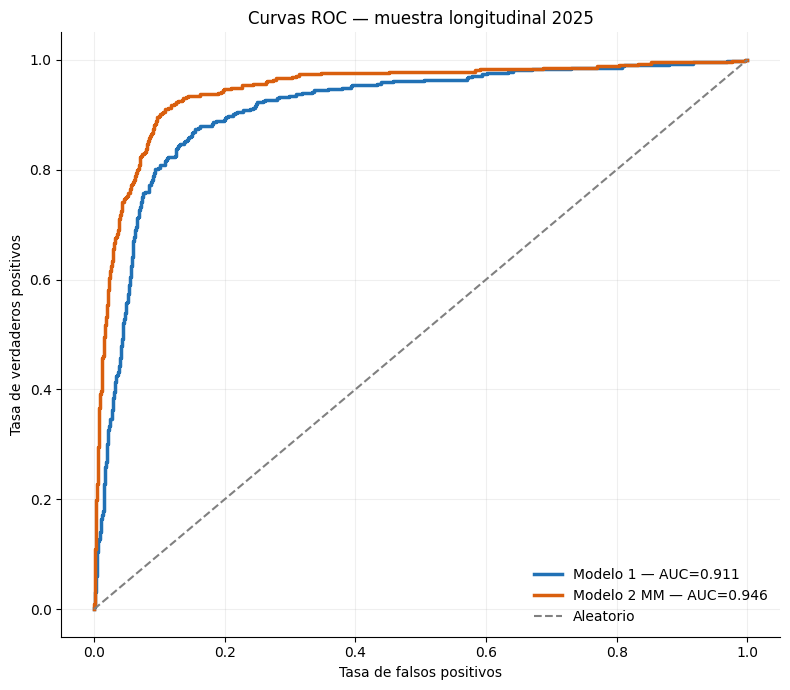

In [23]:
fpr1, tpr1, _ = roc_curve(y_observado_2025, probabilidad_modelo_1)
fpr2, tpr2, _ = roc_curve(y_observado_2025, probabilidad_modelo_2)
auc1 = roc_auc_score(y_observado_2025, probabilidad_modelo_1)
auc2 = roc_auc_score(y_observado_2025, probabilidad_modelo_2)
fig, ax = plt.subplots(figsize=(8,7))
ax.plot(fpr1,tpr1,color="#2171b5",linewidth=2.5,label=f"Modelo 1 — AUC={auc1:.3f}")
ax.plot(fpr2,tpr2,color="#d95f0e",linewidth=2.5,label=f"Modelo 2 MM — AUC={auc2:.3f}")
ax.plot([0,1],[0,1],"--",color="gray",label="Aleatorio")
ax.set_title("Curvas ROC — muestra longitudinal 2025")
ax.set_xlabel("Tasa de falsos positivos"); ax.set_ylabel("Tasa de verdaderos positivos")
ax.legend(frameon=False,loc="lower right"); ax.grid(alpha=.2)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("TP3_C1_curvas_ROC_grupo7.png",dpi=300,bbox_inches="tight")
plt.show()


# C.2 — Trade-off de umbrales y elección del modelo

In [24]:
def evaluar_umbrales(y, p, nombre, umbrales=np.arange(.10,.81,.05)):
    out=[]
    for u in umbrales:
        yh=(p>u).astype(int)
        tn,fp,fn,tp=confusion_matrix(y,yh,labels=[0,1]).ravel()
        out.append({
            "Modelo":nombre,"Umbral":u,"Personas_seleccionadas":int(yh.sum()),
            "Verdaderos_positivos":tp,"Falsos_positivos":fp,"Falsos_negativos":fn,"Verdaderos_negativos":tn,
            "Precision":precision_score(y,yh,zero_division=0),
            "Sensibilidad":recall_score(y,yh,zero_division=0),
            "Especificidad":tn/(tn+fp),"F1_score":f1_score(y,yh,zero_division=0)
        })
    return pd.DataFrame(out)

tabla_umbrales = pd.concat([
    evaluar_umbrales(y_observado_2025,probabilidad_modelo_1,"Modelo 1"),
    evaluar_umbrales(y_observado_2025,probabilidad_modelo_2,"Modelo 2 MM")
],ignore_index=True)
tabla_umbrales.loc[tabla_umbrales["Umbral"].round(2).isin([.20,.25,.30,.35,.40,.50])].round(4)


,Modelo,Umbral,Personas_seleccionadas,Verdaderos_positivos,Falsos_positivos,Falsos_negativos,Verdaderos_negativos,Precision,Sensibilidad,Especificidad,F1_score
2,Modelo 1,0.2000,511,313,198,100,2402,0.6125,0.7579,0.9238,0.6775
3,Modelo 1,0.2500,490,303,187,110,2413,0.6184,0.7337,0.9281,0.6711
4,Modelo 1,0.3000,477,297,180,116,2420,0.6226,0.7191,0.9308,0.6674
5,Modelo 1,0.3500,456,287,169,126,2431,0.6294,0.6949,0.9350,0.6605
6,Modelo 1,0.4000,430,275,155,138,2445,0.6395,0.6659,0.9404,0.6524
8,Modelo 1,0.5000,345,222,123,191,2477,0.6435,0.5375,0.9527,0.5858
17,Modelo 2 MM,0.2000,572,353,219,60,2381,0.6171,0.8547,0.9158,0.7168
18,Modelo 2 MM,0.2500,512,333,179,80,2421,0.6504,0.8063,0.9312,0.7200
19,Modelo 2 MM,0.3000,463,316,147,97,2453,0.6825,0.7651,0.9435,0.7215
20,Modelo 2 MM,0.3500,422,306,116,107,2484,0.7251,0.7409,0.9554,0.7329


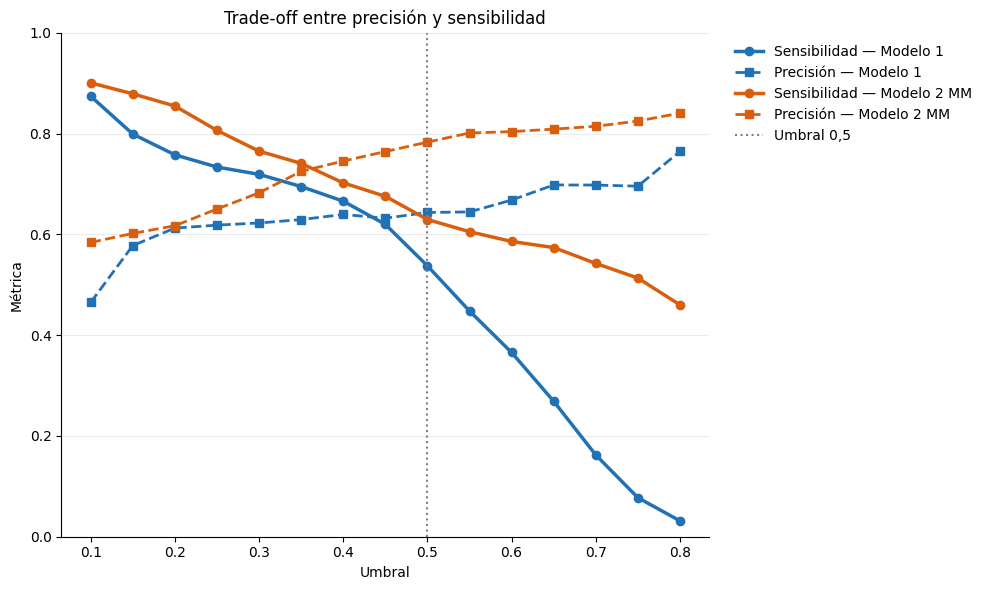

In [25]:
fig, ax = plt.subplots(figsize=(10,6))
for modelo,color in [("Modelo 1","#2171b5"),("Modelo 2 MM","#d95f0e")]:
    d=tabla_umbrales.loc[tabla_umbrales["Modelo"].eq(modelo)]
    ax.plot(d["Umbral"],d["Sensibilidad"],color=color,linewidth=2.5,marker="o",label=f"Sensibilidad — {modelo}")
    ax.plot(d["Umbral"],d["Precision"],color=color,linewidth=2,linestyle="--",marker="s",label=f"Precisión — {modelo}")
ax.axvline(.5,color="gray",linestyle=":",label="Umbral 0,5")
ax.set_title("Trade-off entre precisión y sensibilidad")
ax.set_xlabel("Umbral"); ax.set_ylabel("Métrica"); ax.set_ylim(0,1)
ax.legend(frameon=False,bbox_to_anchor=(1.02,1),loc="upper left"); ax.grid(axis="y",alpha=.25)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("TP3_C2_tradeoff_umbrales_grupo7.png",dpi=300,bbox_inches="tight")
plt.show()


In [26]:
costo_falso_positivo = 1
costo_falso_negativo = 3
tabla_umbrales["Costo_total"] = (
    costo_falso_positivo*tabla_umbrales["Falsos_positivos"]
    + costo_falso_negativo*tabla_umbrales["Falsos_negativos"]
)
mejor_decision_costos = (
    tabla_umbrales.sort_values("Costo_total").groupby("Modelo",as_index=False).first()
)
mejor_decision_costos[[
    "Modelo","Umbral","Falsos_positivos","Falsos_negativos",
    "Precision","Sensibilidad","F1_score","Costo_total"
]].round(4)


,Modelo,Umbral,Falsos_positivos,Falsos_negativos,Precision,Sensibilidad,F1_score,Costo_total
0,Modelo 1,0.1500,241,83,0.5779,0.7990,0.6707,490
1,Modelo 2 MM,0.1000,265,41,0.5840,0.9007,0.7086,388


# D — Reflexión sobre IA

**Herramienta utilizada:** M365 Copilot, basado en un modelo de razonamiento GPT-5.

> Para la realización del trabajo utilizamos M365 Copilot como herramienta de apoyo para organizar el código, revisar la construcción de las muestras de entrenamiento y testeo, implementar las regresiones logísticas y calcular las métricas de clasificación. La asistencia resultó especialmente útil para detectar posibles fugas de información, verificar la correspondencia longitudinal mediante los identificadores de la EPH, automatizar tablas y gráficos y explicar coeficientes, odds ratios, efectos marginales, matrices de confusión y curvas ROC. La herramienta fue menos efectiva en decisiones dependientes de criterios sustantivos, como la definición asignada de informalidad, la selección de predictores y la valoración relativa de falsos positivos y negativos, que requirieron revisar la consigna y los resultados. La IA se utilizó como asistencia para programar, revisar e interpretar, pero no como sustituto de la validación conceptual y estadística realizada por el grupo.

**Tiempo total:** completar manualmente con las horas reales dedicadas por el grupo.


## Apéndice — Prompts de IA utilizados en el TP3

1. “Perfecto, ahora subo la base de datos creada en excel para que trabajes en la hoja de ocupados. la idea es que me ayudes a resolver las consignas del tp3”
2. “ok”
3. “continua”
4. “continua con la otra parte”
5. “ok”
6. “Sí, continúa con B.2”
7. “continua”
8. “ok”
9. “ok”
10. “continúa con C.2”
11. “continua”
12. “perfecto, ahora quiero que me compiles todas las partes y me pases un notebook final, pero solo de la parte del tp3, es decir, compila los códigos después de haber subido la base final de ocupados en excel y la consigna del tp3. Por favor, considera todos los códigos y que coincida con las códigos individuales que me estuviste proporcionando”


# Exportación conjunta de resultados del TP3

In [27]:
resultados_individuales_C1 = ocupados_2025_MM_con_id[
    ["CODUSU","NRO_HOGAR","COMPONENTE","y_2025"]
].copy()
resultados_individuales_C1["probabilidad_modelo_1"] = probabilidad_modelo_1
resultados_individuales_C1["prediccion_modelo_1"] = prediccion_modelo_1
resultados_individuales_C1["probabilidad_modelo_2"] = probabilidad_modelo_2
resultados_individuales_C1["prediccion_modelo_2"] = prediccion_modelo_2

nombre_salida = "TP3_resultados_completos_grupo7.xlsx"
with pd.ExcelWriter(nombre_salida, engine="openpyxl") as writer:
    resumen_bases.to_excel(writer, sheet_name="A1_resumen_bases", index=False)
    tabla_transicion.to_excel(writer, sheet_name="A1_transicion")
    tabla_balance_formateada.to_excel(writer, sheet_name="A2_balance", index=False)
    tabla_ausentes.to_excel(writer, sheet_name="A2_ausentes", index=False)
    tabla_modelos_final.to_excel(writer, sheet_name="B1_modelos", index=False)
    tabla_efectos_marginales.to_excel(writer, sheet_name="B1_efectos_marginales", index=False)
    tabla_ajuste.to_excel(writer, sheet_name="B1_ajuste", index=False)
    resumen_educacion.to_excel(writer, sheet_name="B2_educacion", index=False)
    tabla_metricas_formateada.to_excel(writer, sheet_name="C1_metricas", index=False)
    resultados_individuales_C1.to_excel(writer, sheet_name="C1_predicciones", index=False)
    tabla_umbrales.to_excel(writer, sheet_name="C2_umbrales", index=False)
    mejor_decision_costos.to_excel(writer, sheet_name="C2_costos", index=False)
print("Archivo creado:", nombre_salida)


Archivo creado: TP3_resultados_completos_grupo7.xlsx


In [28]:
files.download("TP3_resultados_completos_grupo7.xlsx")
files.download("TP3_B2_probabilidad_educacion_grupo7.png")
files.download("TP3_C1_matrices_confusion_grupo7.png")
files.download("TP3_C1_curvas_ROC_grupo7.png")
files.download("TP3_C2_tradeoff_umbrales_grupo7.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Observación metodológica final

El modelo 1 fue entrenado en 2024 y evaluado en 2025, por lo que su evaluación es temporalmente fuera de muestra. El modelo 2 MM fue estimado y evaluado en la misma muestra longitudinal de 2025; su desempeño puede ser optimista. Esta diferencia debe mencionarse en el informe.
